# Giai đoạn 5: Đánh giá Toàn bộ các Mô hình trên tập dữ liệu Sạch
Áp dụng phương pháp Lọc nhiễu (Outlier Removal) và huấn luyện lại TẤT CẢ các thuật toán để xem thuật toán nào hưởng lợi nhiều nhất từ dữ liệu sạch. Chúng ta sẽ hiển thị Confusion Matrix và Accuracy cho từng mô hình.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Thuật toán
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
import xgboost as xgb
import lightgbm as lgb

### 1. Đọc dữ liệu và Lọc Nhiễu

In [2]:
df = pd.read_csv('../../data/features/mimic_train_features.csv')

# Lọc bỏ nhiễu
noise_cond_1 = (df['status'] == 0) & ((df['SDNN'] > 300) | (df['RMSSD'] > 400) | (df['pNN50'] > 90))
noise_cond_2 = (df['status'] == 1) & (df['SDNN'] < 50) & (df['pNN50'] < 20)
df_clean = df[~(noise_cond_1 | noise_cond_2)].copy()

X_clean = df_clean.drop(columns=['status'])
y_clean = df_clean['status']

X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean)
print(f"Tập Train: {len(X_train)} mẫu | Tập Test: {len(X_test)} mẫu")

Tập Train: 1060 mẫu | Tập Test: 265 mẫu


### 2. Định nghĩa các mô hình và Huấn luyện đồng loạt

In [3]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
    "SVM": SVC(random_state=42, probability=True),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1), # Đã fix lỗi LinAlgError
    "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    "LightGBM": lgb.LGBMClassifier(random_state=42, verbose=-1)
}

results = []
confusion_matrices = {}

os.makedirs('../../models/clean_compare', exist_ok=True)

for name, model in models.items():
    print(f"Đang huấn luyện: {name}...")
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # Tính metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })
    
    # Lưu Confusion Matrix để vẽ lưới
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)
    
    # Lưu mô hình
    joblib.dump(pipeline, f"../../models/clean_compare/{name.replace(' ', '_').lower()}.pkl")

print("\n✅ Huấn luyện hoàn tất toàn bộ!")

Đang huấn luyện: Logistic Regression...
Đang huấn luyện: Decision Tree...
Đang huấn luyện: Random Forest...
Đang huấn luyện: Extra Trees...
Đang huấn luyện: SVM...
Đang huấn luyện: KNN...
Đang huấn luyện: Naive Bayes...
Đang huấn luyện: LDA...
Đang huấn luyện: QDA...
Đang huấn luyện: XGBoost...
Đang huấn luyện: LightGBM...

✅ Huấn luyện hoàn tất toàn bộ!


### 3. Vẽ Lưới Confusion Matrix cho TẤT CẢ mô hình

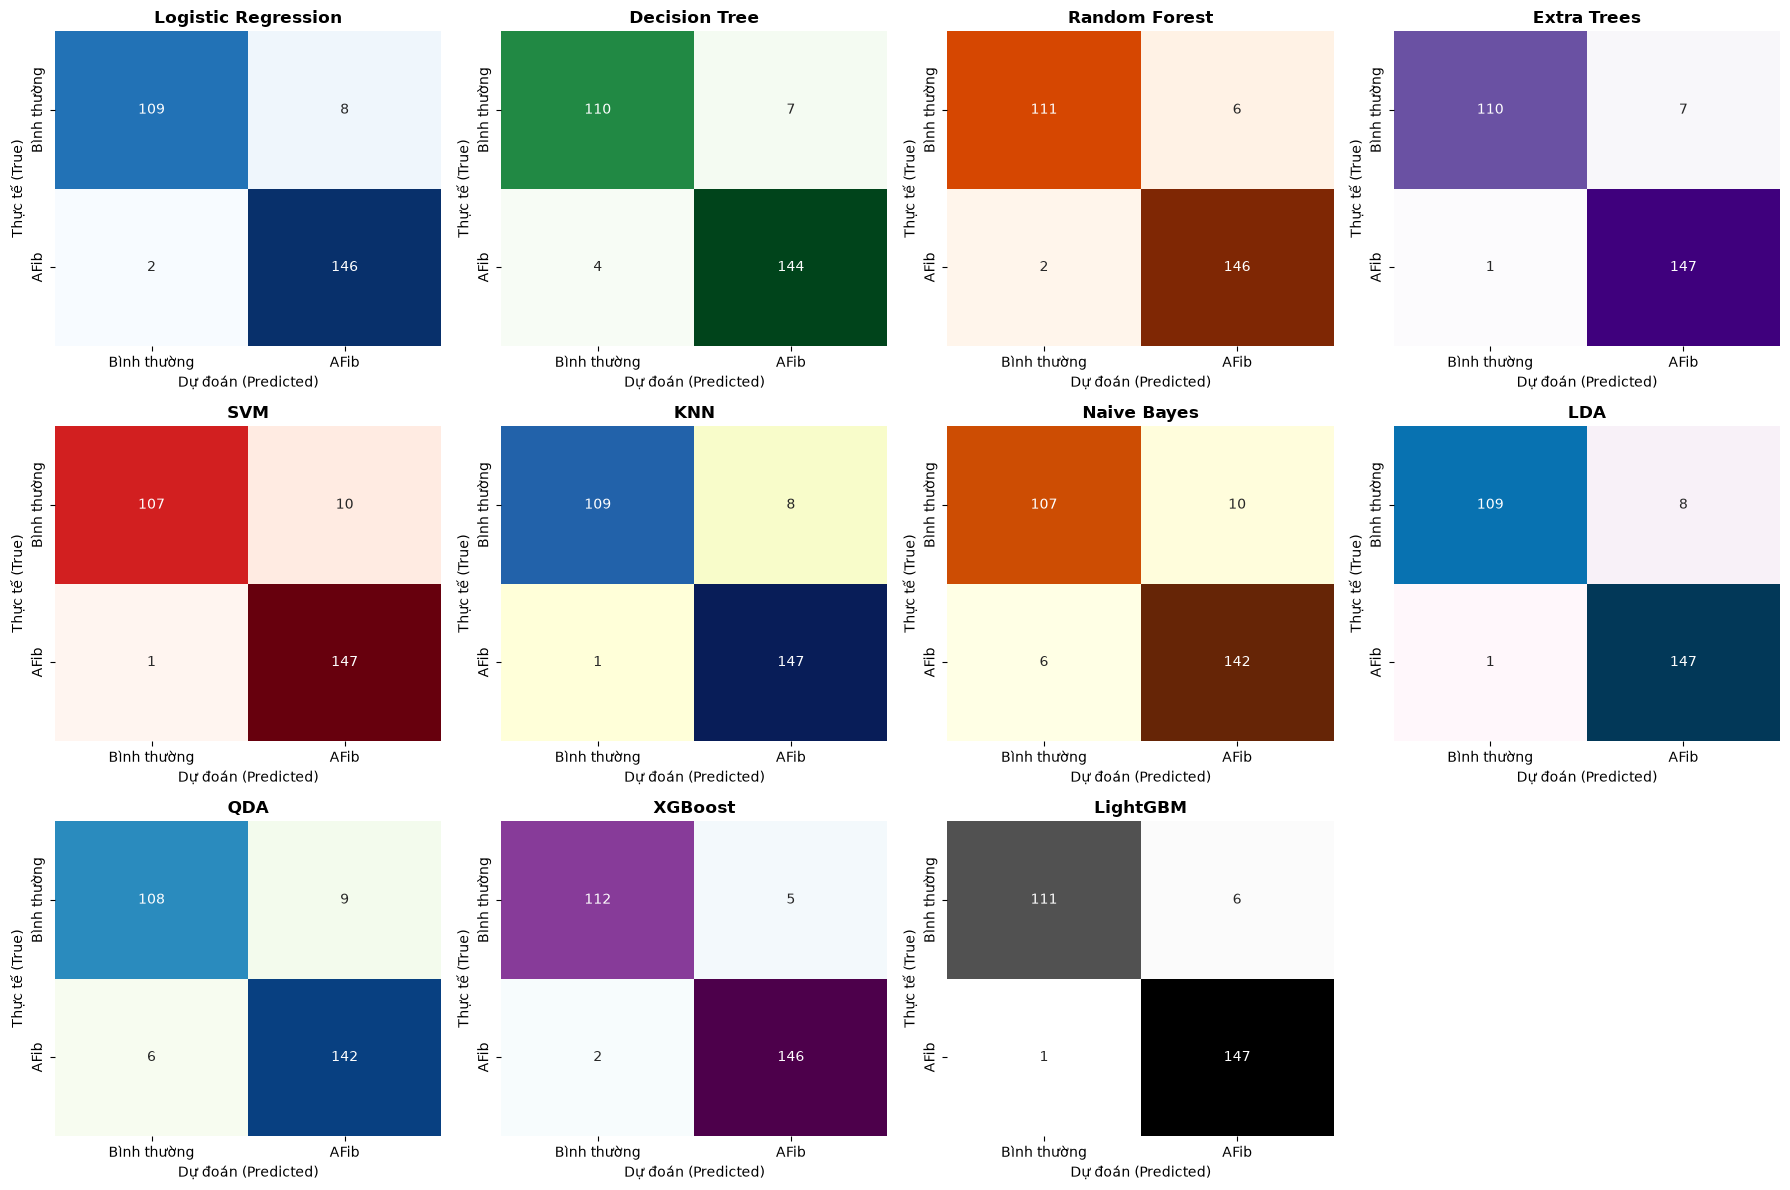

In [6]:
# Danh sách 11 dải màu khác nhau cho 11 mô hình
cmaps = ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds', 
         'YlGnBu', 'YlOrBr', 'PuBu', 'GnBu', 'BuPu', 'Greys']

# Tạo lưới 3 hàng 4 cột (để đủ chứa 11 mô hình)
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, (name, cm) in enumerate(confusion_matrices.items()):
    # Gán mỗi mô hình với một màu tương ứng trong danh sách cmaps
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmaps[i], ax=axes[i], cbar=False)
    
    axes[i].set_title(name, fontweight='bold', fontsize=12)
    axes[i].set_ylabel('Thực tế (True)', fontsize=10)
    axes[i].set_xlabel('Dự đoán (Predicted)', fontsize=10)
    axes[i].set_xticklabels(['Bình thường', 'AFib'])
    axes[i].set_yticklabels(['Bình thường', 'AFib'])

# Xoá ô trống cuối cùng (vì lưới có 12 ô nhưng chỉ có 11 mô hình)
fig.delaxes(axes[11])

plt.tight_layout()
plt.show()

### 4. So sánh Accuracy (AC) giữa các mô hình

,Model,Accuracy,Precision,Recall,F1-Score
0,XGBoost,0.973585,0.966887,0.986486,0.976589
1,LightGBM,0.973585,0.960784,0.993243,0.976744
2,Random Forest,0.969811,0.960526,0.986486,0.973333
3,Extra Trees,0.969811,0.954545,0.993243,0.973510
4,KNN,0.966038,0.948387,0.993243,0.970297
5,LDA,0.966038,0.948387,0.993243,0.970297
6,Logistic Regression,0.962264,0.948052,0.986486,0.966887
7,Decision Tree,0.958491,0.953642,0.972973,0.963211
8,SVM,0.958491,0.936306,0.993243,0.963934
9,QDA,0.943396,0.940397,0.959459,0.949833


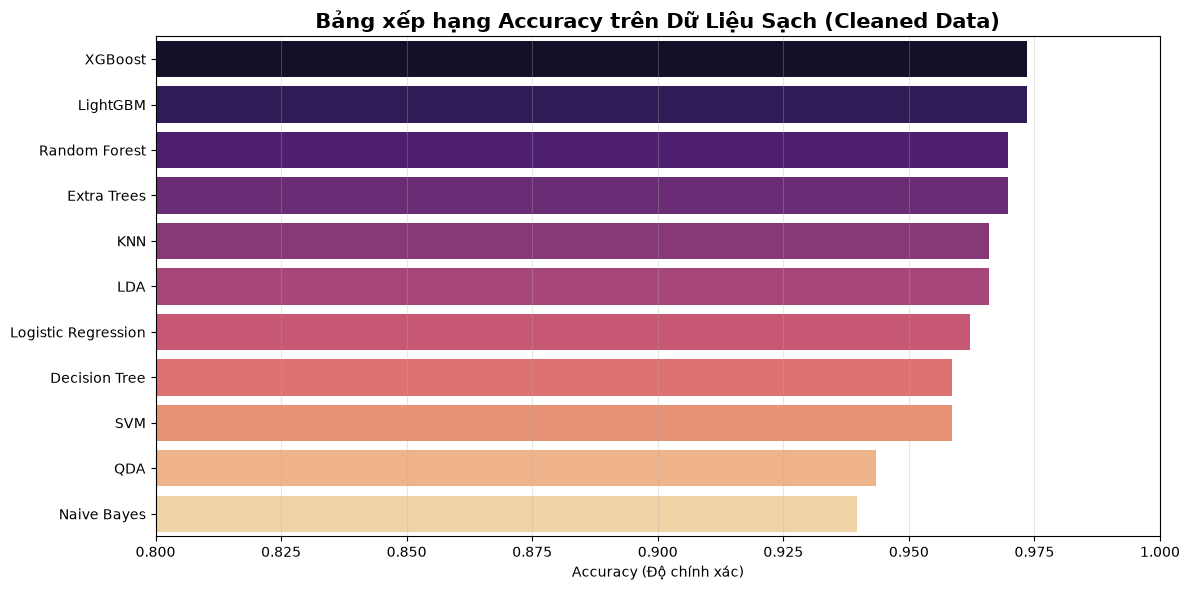

In [ ]:
from IPython.display import display
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

display(results_df)

plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="Accuracy", y="Model", palette="magma")
plt.title("Bảng xếp hạng Accuracy trên Dữ Liệu Sạch (Cleaned Data)", fontsize=15, fontweight='bold')
plt.xlabel("Accuracy (Độ chính xác)")
plt.ylabel("")
plt.xlim([0.8, 1.0]) # Giới hạn trục X để nhìn rõ sự chênh lệch nhỏ
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()